In [3]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from keras.applications import efficientnet
from keras.layers import TextVectorization

keras.utils.set_random_seed(111)

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil7280/coco-image-caption")

print("Path to dataset files:", path)

/home/desktop-amar/miniforge3/envs/yolo_greedy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/desktop-amar/.cache/kagglehub/datasets/nikhil7280/coco-image-caption/versions/1


In [5]:
import json
train_img_dir = os.path.join(path, "train2014", "train2014")
#construct the path towards the captions
ann_path = os.path.join(
    path,
    "annotations_trainval2014",
    "annotations",
    "captions_train2014.json"
)
with open(ann_path, "r") as f:
    data = json.load(f)
image_id_to_file = {
    img["id"]: img["file_name"]
    for img in data["images"]
}
#construct the list images/captions
captions = []
image_paths = []
caption_mapping = {}

#we loop in the annotations
for ann in data["annotations"]:
    #we get the name of the image
    img_file = image_id_to_file[ann["image_id"]]

    img_name = os.path.join(train_img_dir, img_file)
    caption = ["<start> " + ann["caption"] + " <end>"]
    '''
    if img_name in caption_mapping:
        caption_mapping[img_name].append(caption)
    else:
        caption_mapping[img_name] = [caption]
    '''
    
    image_paths.append(img_name)
    captions.append(caption)

#at the end image_paths[i] and captions[i] go together

In [6]:
# Desired image dimensions
IMAGE_SIZE = (299, 299)

# Vocabulary size
VOCAB_SIZE = 10000

# Fixed length allowed for any sequence
SEQ_LENGTH = 25

# Dimension for the image embeddings and token embeddings
EMBED_DIM = 512

# Per-layer units in the feed-forward network
FF_DIM = 512

# Other training parameters
BATCH_SIZE = 64
INIT_LR = 1e-4
EPOCHS = 100
PATIENCE = 10
AUTOTUNE = tf.data.AUTOTUNE

In [7]:
'''
def load_captions_data(filename):
    """Loads captions (text) data and maps them to corresponding images.

    Args:
        filename: Path to the text file containing caption data.

    Returns:
        caption_mapping: Dictionary mapping image names and the corresponding captions
        text_data: List containing all the available captions
    """

    with open(filename) as caption_file:
        caption_data = caption_file.readlines()
        caption_mapping = {}
        text_data = []
        images_to_skip = set()

        for line in caption_data:
            line = line.rstrip("\n")
            # Image name and captions are separated using a tab
            img_name, caption = line.split("\t")

            # Each image is repeated five times for the five different captions.
            # Each image name has a suffix `#(caption_number)`
            img_name = img_name.split("#")[0]
            img_name = os.path.join(IMAGES_PATH, img_name.strip())

            # We will remove caption that are either too short to too long
            tokens = caption.strip().split()

            if len(tokens) < 5 or len(tokens) > SEQ_LENGTH:
                images_to_skip.add(img_name)
                continue

            if img_name.endswith("jpg") and img_name not in images_to_skip:
                # We will add a start and an end token to each caption
                caption = "<start> " + caption.strip() + " <end>"
                text_data.append(caption)

                if img_name in caption_mapping:
                    caption_mapping[img_name].append(caption)
                else:
                    caption_mapping[img_name] = [caption]

        for img_name in images_to_skip:
            if img_name in caption_mapping:
                del caption_mapping[img_name]

        return caption_mapping, text_data
'''

def train_val_split(caption_data, train_size=0.8, shuffle=True):
    """Split the captioning dataset into train and validation sets.

    Args:
        caption_data (dict): Dictionary containing the mapped caption data
        train_size (float): Fraction of all the full dataset to use as training data
        shuffle (bool): Whether to shuffle the dataset before splitting

    Returns:
        Traning and validation datasets as two separated dicts
    """

    # 1. Get the list of all image names
    all_images = list(caption_data.keys())

    # 2. Shuffle if necessary
    if shuffle:
        np.random.shuffle(all_images)

    # 3. Split into training and validation sets
    train_size = int(len(caption_data) * train_size)
    test_size =int((len(caption_data) - train_size)/2)

    training_data = {
        img_name: caption_data[img_name] for img_name in all_images[:train_size]
    }
    validation_data = {
        img_name: caption_data[img_name] for img_name in all_images[train_size:(test_size+train_size)]
    }

    test_data = {img_name: caption_data[img_name] for img_name in all_images[(test_size+train_size):]}

    # 4. Return the splits
    return training_data, validation_data, test_data


# Load the dataset
text_data = captions
captions_mapping = dict(zip(image_paths, captions))
# Split the dataset into training and validation sets
train_data, valid_data, test_data = train_val_split(captions_mapping)
print("Number of training samples: ", len(train_data))
print("Number of validation samples: ", len(valid_data))
print("Number of test samples: ", len(test_data))

Number of training samples:  66226
Number of validation samples:  8278
Number of test samples:  8279


In [8]:
def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(lowercase, "[%s]" % re.escape(strip_chars), "")


strip_chars = "!\"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"
strip_chars = strip_chars.replace("<", "") #Borde kunna tas bort om man tar bort dom ovan??
strip_chars = strip_chars.replace(">", "")

vectorization = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQ_LENGTH,
    standardize=custom_standardization,
)
vectorization.adapt(text_data)

VOCAB_SIZE = len(vectorization.get_vocabulary())

# Data augmentation for image data
image_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomContrast(0.3),
    ]
)

I0000 00:00:1779796325.599702   36304 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21289 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


In [9]:
def decode_and_resize(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.image.convert_image_dtype(img, tf.float32)
    return img


def process_input(img_path, captions):
    return decode_and_resize(img_path), vectorization(captions)


def make_dataset(images, captions):
    dataset = tf.data.Dataset.from_tensor_slices((images, captions))
    dataset = dataset.shuffle(BATCH_SIZE * 8)
    dataset = dataset.map(process_input, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return dataset


# Pass the list of images and the list of corresponding captions
"""import numpy as np

train_dataset = make_dataset(
    np.array(list(train_data.keys())),
    np.array(list(train_data.values()))
)
valid_dataset = make_dataset(
    np.array(list(valid_data.keys())),
    np.array(list(valid_data.values()))
)
test_dataset = make_dataset(
    np.array(list(test_data.keys())),
    np.array(list(test_data.values()))
)"""

train_dataset = make_dataset(list(train_data.keys()), list(train_data.values()))

valid_dataset = make_dataset(list(valid_data.keys()), list(valid_data.values()))

test_dataset = make_dataset(list(test_data.keys()), list(test_data.values()))

In [10]:
def get_cnn_model():
    base_model = efficientnet.EfficientNetB0(
        input_shape=(*IMAGE_SIZE, 3),
        include_top=False, #Disable classification, only get the mapping
        weights="imagenet",
    )
    # We freeze our feature extractor
    base_model.trainable = False
    base_model_out = base_model.output
    base_model_out = layers.Reshape((-1, base_model_out.shape[-1]))(base_model_out) #Flattening
    cnn_model = keras.models.Model(base_model.input, base_model_out)
    return cnn_model


class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention_1 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim, dropout=0.0
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.dense_1 = layers.Dense(embed_dim, activation="relu")
    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "dense_dim": self.dense_dim,
            "num_heads": self.num_heads,
        })
        return config

    def call(self, inputs, training, mask=None): #Forward pass
        inputs = self.layernorm_1(inputs)
        inputs = self.dense_1(inputs)

        attention_output_1 = self.attention_1(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=None,
            training=training,
        )
        out_1 = self.layernorm_2(inputs + attention_output_1)
        return out_1


class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim
        )
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=embed_dim
        )
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.embed_scale = tf.math.sqrt(tf.cast(embed_dim, tf.float32)) #Scaling so position doesnt get left out
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
        })
        return config

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_tokens = embedded_tokens * self.embed_scale
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions #Addition, token + position

    def compute_mask(self, inputs, mask=None):
        return tf.math.not_equal(inputs, 0) #checks for words, not padding


class TransformerDecoderBlock(layers.Layer):
    def __init__(self, embed_dim, ff_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.ff_dim = ff_dim
        self.num_heads = num_heads
        self.attention_1 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim, dropout=0.1
        )
        self.attention_2 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim, dropout=0.1
        )
        self.ffn_layer_1 = layers.Dense(ff_dim, activation="relu")
        self.ffn_layer_2 = layers.Dense(embed_dim)

        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()

        self.embedding = PositionalEmbedding(
            embed_dim=EMBED_DIM,
            sequence_length=SEQ_LENGTH,
            vocab_size=VOCAB_SIZE,
        )
        self.out = layers.Dense(VOCAB_SIZE, activation="softmax")

        self.dropout_1 = layers.Dropout(0.3)
        self.dropout_2 = layers.Dropout(0.5)
        self.supports_masking = True #Viktigt

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "ff_dim": self.ff_dim,
            "num_heads": self.num_heads,
        })
        return config
    def call(self, inputs, encoder_outputs, training=False, mask=None):
        inputs = self.embedding(inputs)
        causal_mask = self.get_causal_attention_mask(inputs) #needed for training, only looking at the first word

        if mask is not None:
            padding_mask = tf.cast(mask[:, :, tf.newaxis], dtype=tf.int32)
            combined_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.int32)
            combined_mask = tf.minimum(combined_mask, causal_mask) #Combind the mask and padding, to ignore padding

        attention_output_1 = self.attention_1( #For the caption only
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=combined_mask,
            training=training,
        )
        out_1 = self.layernorm_1(inputs + attention_output_1)

        attention_output_2 = self.attention_2( #Caption + image
            query=out_1,
            value=encoder_outputs,
            key=encoder_outputs,
            attention_mask=padding_mask,
            training=training,
        )
        out_2 = self.layernorm_2(out_1 + attention_output_2)

        ffn_out = self.ffn_layer_1(out_2)
        ffn_out = self.dropout_1(ffn_out, training=training)
        ffn_out = self.ffn_layer_2(ffn_out)

        ffn_out = self.layernorm_3(ffn_out + out_2, training=training)
        ffn_out = self.dropout_2(ffn_out, training=training)
        preds = self.out(ffn_out)
        return preds

    def get_causal_attention_mask(self, inputs): #Creates bottom left trianglular matrix, to only make the model see 1 word, 2 words etc.
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, input_shape[1], input_shape[1]))
        mult = tf.concat(
            [
                tf.expand_dims(batch_size, -1),
                tf.constant([1, 1], dtype=tf.int32),
            ],
            axis=0,
        )
        return tf.tile(mask, mult)


class ImageCaptioningModel(keras.Model):
    def __init__(
        self,
        cnn_model,
        encoder,
        decoder,
        num_captions_per_image=5,
        image_aug=None,
    ):
        super().__init__()
        self.cnn_model = cnn_model
        self.encoder = encoder
        self.decoder = decoder
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.acc_tracker = keras.metrics.Mean(name="accuracy")
        self.num_captions_per_image = num_captions_per_image
        self.image_aug = image_aug

    def get_config(self):
        config = super().get_config()
        config.update({
            "cnn_model": self.cnn_model,
            "encoder": self.encoder,
            "decoder": self.decoder,
            "num_captions_per_image": self.num_captions_per_image,
            "image_aug": self.image_aug,
        })
        return config

    def call(self, inputs, training=False):
        batch_img, batch_seq = inputs
        
        # Extract the sequence if it contains the extra num_captions dimension
        if len(batch_seq.shape) == 3:
            batch_seq = batch_seq[:, 0, :]
            
        img_embed = self.cnn_model(batch_img)
        encoder_out = self.encoder(img_embed, training=training)
        
        batch_seq_inp = batch_seq[:, :-1] # include start token not end token
        batch_seq_true = batch_seq[:, 1:] # Include end token not start
        
        mask = tf.math.not_equal(batch_seq_true, 0) # Remove padding
        decoder_out = self.decoder(
            batch_seq_inp, encoder_out, training=training, mask=mask
        )
        return decoder_out
    
    def calculate_loss(self, y_true, y_pred, mask):
        loss = self.loss(y_true, y_pred)
        mask = tf.cast(mask, dtype=loss.dtype)
        loss *= mask
        return tf.reduce_sum(loss) / tf.reduce_sum(mask)

    def calculate_accuracy(self, y_true, y_pred, mask):
        accuracy = tf.equal(y_true, tf.argmax(y_pred, axis=2))
        accuracy = tf.math.logical_and(mask, accuracy)
        accuracy = tf.cast(accuracy, dtype=tf.float32)
        mask = tf.cast(mask, dtype=tf.float32)
        return tf.reduce_sum(accuracy) / tf.reduce_sum(mask)

    def _compute_caption_loss_and_acc(self, img_embed, batch_seq, training=True): 
        encoder_out = self.encoder(img_embed, training=training)
        batch_seq_inp = batch_seq[:, :-1] 
        batch_seq_true = batch_seq[:, 1:] 
        mask = tf.math.not_equal(batch_seq_true, 0) 
        batch_seq_pred = self.decoder(
            batch_seq_inp, encoder_out, training=training, mask=mask
        )
        loss = self.calculate_loss(batch_seq_true, batch_seq_pred, mask)
        acc = self.calculate_accuracy(batch_seq_true, batch_seq_pred, mask)
        return loss, acc 

    def train_step(self, batch_data):
        batch_img, batch_seq = batch_data
        batch_loss = 0
        batch_acc = 0

        if self.image_aug:
            batch_img = self.image_aug(batch_img)

        img_embed = self.cnn_model(batch_img)

        for i in range(self.num_captions_per_image):
            with tf.GradientTape() as tape: 
                loss, acc = self._compute_caption_loss_and_acc(
                    img_embed, batch_seq[:, i, :], training=True
                )
                batch_loss += loss
                batch_acc += acc

            train_vars = (
                self.encoder.trainable_variables + self.decoder.trainable_variables
            )
            grads = tape.gradient(loss, train_vars)
            self.optimizer.apply_gradients(zip(grads, train_vars))

        batch_acc /= float(self.num_captions_per_image)
        self.loss_tracker.update_state(batch_loss)
        self.acc_tracker.update_state(batch_acc)

        return {
            "loss": self.loss_tracker.result(),
            "acc": self.acc_tracker.result(),
        }

    def test_step(self, batch_data):
        batch_img, batch_seq = batch_data
        batch_loss = 0
        batch_acc = 0

        img_embed = self.cnn_model(batch_img)

        for i in range(self.num_captions_per_image):
            loss, acc = self._compute_caption_loss_and_acc(
                img_embed, batch_seq[:, i, :], training=False
            )
            batch_loss += loss
            batch_acc += acc

        batch_acc /= float(self.num_captions_per_image)

        self.loss_tracker.update_state(batch_loss)
        self.acc_tracker.update_state(batch_acc)

        return {
            "loss": self.loss_tracker.result(),
            "acc": self.acc_tracker.result(),
        }

    @property
    def metrics(self):
        return [self.loss_tracker, self.acc_tracker]


cnn_model = get_cnn_model()
encoder = TransformerEncoderBlock(embed_dim=EMBED_DIM, dense_dim=FF_DIM, num_heads=1)
decoder = TransformerDecoderBlock(embed_dim=EMBED_DIM, ff_dim=FF_DIM, num_heads=2)
caption_model = ImageCaptioningModel(
    cnn_model=cnn_model,
    encoder=encoder,
    decoder=decoder,
    num_captions_per_image=1,
    image_aug=image_augmentation,
)

In [11]:
 # Define the loss function
print("start")
import sys
import tensorflow as tf
print("1. Python is running from:", sys.executable)
print("2. GPUs Available to TensorFlow:", len(tf.config.list_physical_devices('GPU')))

cross_entropy = keras.losses.SparseCategoricalCrossentropy(
    from_logits=False, #?
    reduction=None, #?
)

# EarlyStopping criteria
early_stopping = keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True)

@keras.saving.register_keras_serializable()
class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_learning_rate, warmup_steps, total_steps, **kwargs):
        super().__init__()
        self.initial_learning_rate = float(initial_learning_rate)
        self.warmup_steps = int(warmup_steps)
        self.total_steps = int(total_steps)

    def __call__(self, step):
        global_step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        total_steps = tf.cast(self.total_steps, tf.float32)
        init_lr = tf.cast(self.initial_learning_rate, tf.float32)

        # 1. Warmup phase (straight line up)
        warmup_lr = init_lr * (global_step / warmup_steps)

        # 2. Cosine Decay phase (smooth curve down to zero)
        decay_steps = total_steps - warmup_steps
        decay_step = tf.math.minimum(global_step - warmup_steps, decay_steps)
        cosine_decay = 0.5 * (1.0 + tf.math.cos(3.14159265359 * (decay_step / decay_steps)))
        decayed_lr = init_lr * cosine_decay

        return tf.cond(
            global_step < warmup_steps,
            lambda: warmup_lr,
            lambda: decayed_lr,
        )

    def get_config(self):
        return {
            "initial_learning_rate": self.initial_learning_rate,
            "warmup_steps": self.warmup_steps,
            "total_steps": self.total_steps,
        }

# Learning Rate Scheduler for the optimizer
class LRSchedule(keras.optimizers.schedules.LearningRateSchedule): #Needed for transformers
    def __init__(self, post_warmup_learning_rate, warmup_steps):
        super().__init__()
        self.post_warmup_learning_rate = post_warmup_learning_rate
        self.warmup_steps = warmup_steps
    def get_config(self):
        return {
            "post_warmup_learning_rate": self.post_warmup_learning_rate,
            "warmup_steps": self.warmup_steps,
        }

    def __call__(self, step):
        global_step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        warmup_progress = global_step / warmup_steps
        warmup_learning_rate = self.post_warmup_learning_rate * warmup_progress
        return tf.cond(
            global_step < warmup_steps,
            lambda: warmup_learning_rate,
            lambda: self.post_warmup_learning_rate,
        )

# Create a learning rate schedule
num_train_steps = len(train_dataset) * EPOCHS
num_warmup_steps = num_train_steps // 15
#lr_schedule = LRSchedule(post_warmup_learning_rate=INIT_LR, warmup_steps=num_warmup_steps)
lr_schedule = WarmupCosineDecay(
    initial_learning_rate=INIT_LR, 
    warmup_steps=num_warmup_steps, 
    total_steps=num_train_steps  # Now it knows how long the whole training is!
)

print("init wandb")
import wandb
wandb.init(
    project="Lab3_Kerasb",
    name="Lab3_Kerasb_Amar",
    config={
        "learning_rate": lr_schedule,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "early_stopping": early_stopping,
    }
)

config = wandb.config
print("wandb done")

# Compile the model
#caption_model.compile(optimizer=keras.optimizers.Adam(lr_schedule), loss=cross_entropy)
caption_model.compile(
    optimizer=keras.optimizers.Adam(lr_schedule),
    loss=cross_entropy,
    metrics=['accuracy']
)
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model_lab3b.weights.h5",          # nom du fichier
    monitor="val_loss",       # on surveille la validation
    save_best_only=True,      # garde seulement le meilleur
    mode="min",               # plus petite loss = mieux
    verbose=1,
    save_weights_only=True
)

from wandb.integration.keras import WandbCallback

for batch in train_dataset.take(1):
    caption_model(batch, training=False)

print(caption_model.built)

train_dataset = train_dataset.prefetch(buffer_size=2)
valid_dataset = valid_dataset.prefetch(buffer_size=2)

# 1. Import the modern logger
from wandb.integration.keras import WandbMetricsLogger

# 2. Update your .fit() callbacks
caption_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=valid_dataset,
    callbacks=[
        early_stopping,
        checkpoint,
        WandbMetricsLogger() # Replaces the old WandbCallback
    ],
)

start
1. Python is running from: /home/desktop-amar/miniforge3/envs/yolo_greedy/bin/python
2. GPUs Available to TensorFlow: 1
init wandb


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/desktop-amar/.netrc.
wandb: Currently logged in as: linneahejsupergroup (linneahejsupergroup-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb done


/home/desktop-amar/miniforge3/envs/yolo_greedy/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'image_captioning_model', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
I0000 00:00:1779796333.008195   36304 cuda_dnn.cc:529] Loaded cuDNN version 90300


True
Epoch 1/100


2026-05-26 13:52:14.364169: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1035/1035 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - acc: 0.0721 - loss: 8.4426
Epoch 1: val_loss improved from None to 5.29006, saving model to best_model_lab3b.weights.h5
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 131s 120ms/step - acc: 0.1434 - loss: 7.2601 - val_acc: 0.2236 - val_loss: 5.2901
Epoch 2/100
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - acc: 0.2389 - loss: 5.0974
Epoch 2: val_loss improved from 5.29006 to 4.33361, saving model to best_model_lab3b.weights.h5
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 128s 124ms/step - acc: 0.2586 - loss: 4.8653 - val_acc: 0.3077 - val_loss: 4.3336
Epoch 3/100
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - acc: 0.3152 - loss: 4.2522
Epoch 3: val_loss improved from 4.33361 to 3.75162, saving model to best_model_lab3b.weights.h5
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 129s 124ms/step - acc: 0.3274 - loss: 4.1032 - val_acc: 0.3582 - val_loss: 3.7516
Epoch 4/100
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - acc: 0.3564 - loss: 3.7385
Epoch 4: val_loss improved from 3.75162 to 3

2026-05-26 14:19:47.270848: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 134230528 bytes after encountering the first element of size 134230528 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1035/1035 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - acc: 0.4701 - loss: 2.5041
Epoch 14: val_loss improved from 2.73148 to 2.72378, saving model to best_model_lab3b.weights.h5
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 123s 119ms/step - acc: 0.4711 - loss: 2.4936 - val_acc: 0.4603 - val_loss: 2.7238
Epoch 15/100
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - acc: 0.4750 - loss: 2.4589
Epoch 15: val_loss improved from 2.72378 to 2.72033, saving model to best_model_lab3b.weights.h5
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 127s 123ms/step - acc: 0.4760 - loss: 2.4477 - val_acc: 0.4614 - val_loss: 2.7203
Epoch 16/100
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - acc: 0.4789 - loss: 2.4164
Epoch 16: val_loss improved from 2.72033 to 2.71313, saving model to best_model_lab3b.weights.h5
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 129s 124ms/step - acc: 0.4808 - loss: 2.4055 - val_acc: 0.4621 - val_loss: 2.7131
Epoch 17/100
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - acc: 0.4844 - loss: 2.3760
Epoch 17: val_loss did not improve 

[nltk_data] Downloading package wordnet to /home/desktop-
[nltk_data]     amar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


load model
done model
eval:
Bleu  0.32602345345957306 0.18711463660692462 0.11987205926239618 0.07942432302901421
Meteor  0.259119505470166


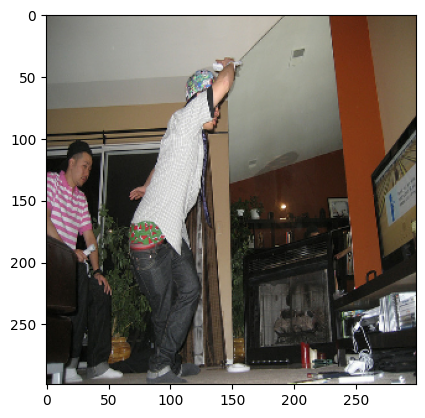

Predicted Caption:  a group of people standing in front of a building


'a group of people standing in front of a building'

In [14]:
import nltk
nltk.download('wordnet')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from tensorflow.keras.models import load_model
print("load model")

image_augmentation
cnn_model = get_cnn_model()
encoder = TransformerEncoderBlock(embed_dim=EMBED_DIM, dense_dim=FF_DIM, num_heads=1)
decoder = TransformerDecoderBlock(embed_dim=EMBED_DIM, ff_dim=FF_DIM, num_heads=2)
caption_model = ImageCaptioningModel(
    cnn_model=cnn_model,
    encoder=encoder,
    decoder=decoder,
    num_captions_per_image=1,
    image_aug=image_augmentation,
)

for batch in test_dataset.take(1):
    caption_model(batch, training=False)

# NOW you can safely load the weights!
caption_model.load_weights("best_model_lab3b_Amar.weights.h5")
print("done model")
def generate_cap(model, image, show=False):

    vocab = vectorization.get_vocabulary()
    index_lookup = dict(zip(range(len(vocab)), vocab))
    max_decoded_sentence_length = SEQ_LENGTH - 1

    # Read the image from the disk
    sample_img = decode_and_resize(image)
    if show:
        img = sample_img.numpy().clip(0, 255).astype(np.uint8)
        plt.imshow(img)
        plt.show()

    # Pass the image to the CNN
    img = tf.expand_dims(sample_img, 0)
    img = model.cnn_model(img)

    # Pass the image features to the Transformer encoder
    encoded_img = model.encoder(img, training=False)

    # Generate the caption using the Transformer decoder
    decoded_caption = "<start> "
    for i in range(max_decoded_sentence_length):
        tokenized_caption = vectorization([decoded_caption])[:, :-1]
        mask = tf.math.not_equal(tokenized_caption, 0)
        predictions = model.decoder(
            tokenized_caption, encoded_img, training=False, mask=mask
        )
        sampled_token_index = np.argmax(predictions[0, i, :])
        sampled_token = index_lookup[sampled_token_index]
        if sampled_token == "<end>":
            break
        decoded_caption += " " + sampled_token

    decoded_caption = decoded_caption.replace("<start> ", "")
    decoded_caption = decoded_caption.replace(" <end>", "").strip()
    if show:
        print("Predicted Caption: ", decoded_caption)
    return decoded_caption

def tokenize(text):
    text = str(text)
    text = text.replace("<start> ", "")
    text = text.replace(" <end>", "").strip()
    return re.findall(r"\w+", str(text).lower())

smooth = SmoothingFunction().method4

#best_model.evaluate(test_dataset)
bleu_scores1       = []
bleu_scores2        = []
bleu_scores3        = []
bleu_scores4        = []
meteor_scores      = []
print("eval:")
for img in test_data:
    ref_tokens  = tokenize(test_data[img])
    pred_tokens = tokenize(generate_cap(caption_model, img, False))

    bleu1        = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth, weights=(1, 0, 0, 0))
    bleu2        = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth, weights=(0.5, 0.5, 0, 0))
    bleu3        = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth, weights=(0.33, 0.33, 0.33, 0))
    bleu4        = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth, weights=(0.25, 0.25, 0.25, 0.25))
    meteor      = meteor_score([ref_tokens], pred_tokens)

    bleu_scores1.append(bleu1)
    bleu_scores2.append(bleu2)
    bleu_scores3.append(bleu3)
    bleu_scores4.append(bleu4)
    meteor_scores.append(meteor)

    avg_bleu1        = sum(bleu_scores1)        / len(bleu_scores1)
    avg_bleu2        = sum(bleu_scores2)        / len(bleu_scores2)
    avg_bleu3        = sum(bleu_scores3)        / len(bleu_scores3)
    avg_bleu4        = sum(bleu_scores4)        / len(bleu_scores4)
    avg_meteor       = sum(meteor_scores)       / len(meteor_scores)
        
# Fixed the typo to show 1, 2, 3, and 4
print("Bleu ", avg_bleu1, avg_bleu2, avg_bleu3, avg_bleu4)
print("Meteor ", avg_meteor)

# Commented this out so it doesn't crash your script!
# caption_model.evaluate(test_dataset)

# Show the generated image
generate_cap(caption_model, np.random.choice(list(test_data.keys())), True)

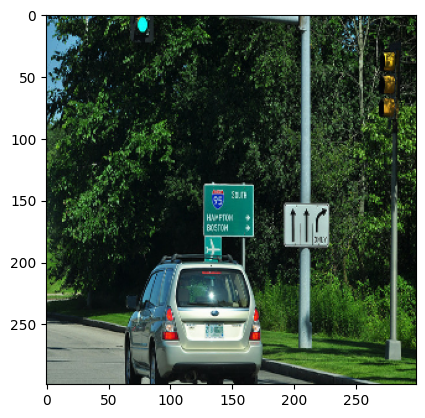

Predicted Caption:  a street sign that is on a pole


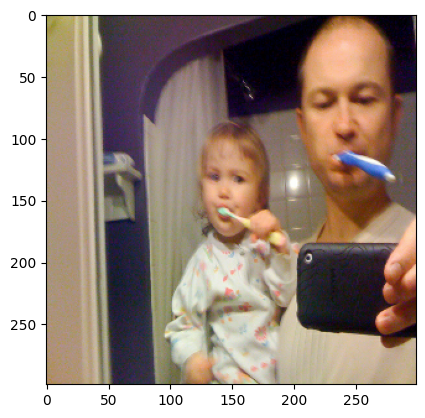

Predicted Caption:  a young boy brushing his teeth with a toothbrush


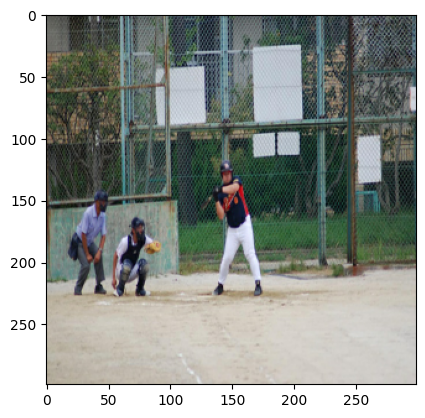

Predicted Caption:  a baseball player is swinging a bat at a ball


In [16]:
vocab = vectorization.get_vocabulary()
index_lookup = dict(zip(range(len(vocab)), vocab))
max_decoded_sentence_length = SEQ_LENGTH - 1
valid_images = list(test_data.keys())

caption_model.load_weights("best_model_lab3b.weights.h5")

#caption_model.evaluate(test_dataset)

def generate_caption():
    # Select a random image from the validation dataset
    sample_img = np.random.choice(valid_images)

    # Read the image from the disk
    sample_img = decode_and_resize(sample_img)
    img = sample_img.numpy().clip(0, 255).astype(np.uint8)
    plt.imshow(img)
    plt.show()

    # Pass the image to the CNN
    img = tf.expand_dims(sample_img, 0)
    img = caption_model.cnn_model(img)

    # Pass the image features to the Transformer encoder
    encoded_img = caption_model.encoder(img, training=False)

    # Generate the caption using the Transformer decoder
    decoded_caption = "<start> "
    for i in range(max_decoded_sentence_length):
        tokenized_caption = vectorization([decoded_caption])[:, :-1]
        mask = tf.math.not_equal(tokenized_caption, 0)
        predictions = caption_model.decoder(
            tokenized_caption, encoded_img, training=False, mask=mask
        )
        sampled_token_index = np.argmax(predictions[0, i, :])
        sampled_token = index_lookup[sampled_token_index]
        if sampled_token == "<end>":
            break
        decoded_caption += " " + sampled_token

    decoded_caption = decoded_caption.replace("<start> ", "")
    decoded_caption = decoded_caption.replace(" <end>", "").strip()
    print("Predicted Caption: ", decoded_caption)


# Check predictions for a few samples
generate_caption()
generate_caption()
generate_caption()